In [1]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [2]:
from Visualization import generalVisualization
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import matplotlib.pyplot as plt
import numpy as np

In [3]:
%cd ../clean_code/

/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code


In [4]:
def scatter_plot(points,transformed_points, data, focus_on, percent_size=0.01, alpha_actual=1, out_file=None, labels=None, num_labels=10):
	"""
	Creates a scatter plot of transformed points with digit images.

	Args:
		transformed_points (np.ndarray): 2D coordinates of points after dimensionality reduction.
		percent_size (float): Relative size of digit images as a fraction of plot range.
		alpha_actual (float): Opacity of digit images (0.0 to 1.0).
		out_file (Optional[str]): If provided, saves the output figure to this file path.
		labels (Optional[np.ndarray]): Labels for coloring points.
		num_labels (int): Number of distinct labels for coloring.
	"""
	if out_file is None:
		out_file = "mnist_visualization.png"

	fig, ax = plt.subplots(figsize=(12, 10))

	# Assign distinct colors for each digit
	colors = visualHelpers.get_distinct_colors(num_labels)

	x_bound = (transformed_points[:, 0].min(), transformed_points[:, 0].max())
	y_bound = (transformed_points[:, 1].min(), transformed_points[:, 1].max())

	image_size = (x_bound[1] + y_bound[1] - x_bound[0] - y_bound[0]) * percent_size / 2

	for i in range(transformed_points.shape[0]):
		alpha_mask = np.clip(data[i].reshape(28, 28), 0, 255) / 255

		point_voltages = points[i, :]

		label = labels[i]

		if (label != None):
			color = np.array(colors[int(label)])
			
			size = 1
			if (np.min(point_voltages) == 0.0):
				#find the index of the minimal voltage
				min_index = np.argmin(point_voltages)
				min_index=focus_on[min_index]
				#plot the number in the current location defined by transformed_points[i]
				plt.text(transformed_points[i, 0], transformed_points[i, 1], str(min_index), fontsize=20, color='white', ha='center', va='center')

			# Create RGBA image
			rgb_image = np.zeros((28, 28, 4))

			for c in range(3):
				rgb_image[..., c] = color[c]
			rgb_image[..., 3] = alpha_mask * alpha_actual  # Alpha from pixel intensity

			x, y = transformed_points[i]
			ax.imshow(rgb_image, extent=(x - image_size * size, x + image_size * size, y - image_size * size, y + image_size * size), origin='upper')
	
	ax.set_xlim(x_bound[0] - image_size , x_bound[1] + image_size)
	ax.set_ylim(y_bound[0] - image_size , y_bound[1] + image_size)
	ax.set_facecolor('black')
	fig.patch.set_facecolor('black')
	plt.title("Visualization of Digits")

	visualHelpers.standard_save_display(out_file)

In [5]:
data_file = "../../Voltage_Temp/Results/mnist/saved_data.pkl"
!ls -l $data_file

-rw-r--r--@ 1 yoavfreund  staff  11367262 Aug 21 18:16 ../../Voltage_Temp/Results/mnist/saved_data.pkl


Plot saved to mnist_visualization.png


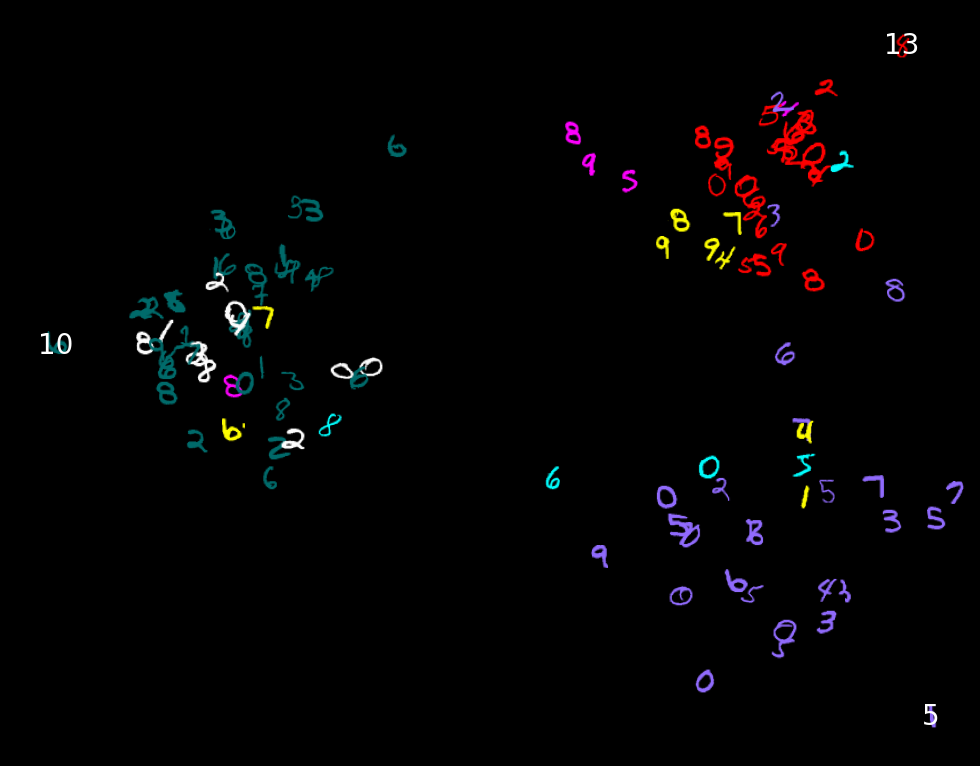

In [7]:

#load data from the pickle file
with open(data_file, 'rb') as f:
    data= pickle.load(f)


voltages= data['voltage_map']
centroids= data['centroids']
labels= data['majority_labels']

#focus_on = np.array(range(20))
# focus_on=np.array([14,19,8,2,1,12])
focus_on=np.array([13,5,10])
# focus_on=np.array([5,7,10,13,18])
# focus_on = np.array([7,10,18]) 
#focus_on = np.array([2,8,14,19]) 

#def plot_mnist_digits(voltages, centroids, labels, 
transformation="pca"; landmarkSize=3; alpha_actual=1; percent_size=0.02; out_file=None; log_transform=True; num_labels=10
"""
Visualizes MNIST digits in 2D space using voltage-based embeddings reduced by PCA or MDS.

Each point in the embedding is rendered as a translucent RGB digit image colored by its label.
Landmark points (voltage = 1) are optionally scaled up to highlight their influence.

"""

points = voltages.voltage_array()

if log_transform:
	points = -np.log(points)	

# identify the points for whom the closest landmark is in focus_on
closest_landmarks=np.argmin(points,axis=1)
mask = np.isin(closest_landmarks, focus_on)


points = points[mask,:]
points = points[:, focus_on] 


labels=np.array(labels)
labels = labels[mask]
labels.shape

transformed_points = visualHelpers.transform(points, transformation)
transformed_points.shape
scatter_plot(points, transformed_points, centroids, focus_on, percent_size=percent_size, alpha_actual=alpha_actual, out_file=out_file, labels=labels, num_labels=num_labels)


In [97]:
points.shape

(1000, 4)

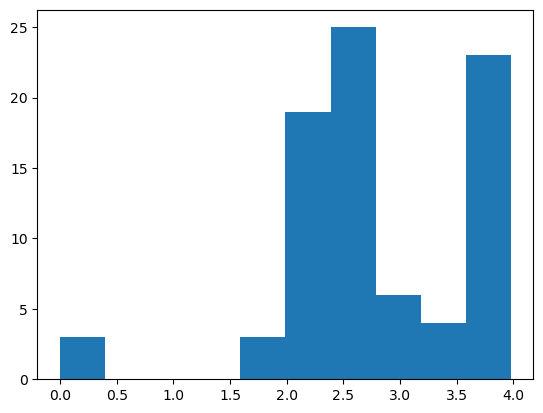

In [82]:
plt.hist(np.min(points,axis=1));

In [74]:
points.shape

(329, 3)